# Outlier Analysis

**Goal:** Identify and (optionally) remove anomalous observations in the continuous
clinical predictors before modelling. Heavy outliers in physiological variables are
often data-entry errors or rare extreme cases that can distort scaling, distance-based
methods and linear models.

This notebook complements `03_feature_analysis` (which characterises feature–outcome
relationships) by focusing purely on the *shape and extremes* of the predictor space.

**Sections:**
1. Imports & data loading
2. Univariate outlier detection (IQR & robust z-score)
3. Distribution & boxplot inspection
4. Multivariate outlier detection (Isolation Forest & Mahalanobis distance)
5. Optional outlier removal (configurable cell)


## 1. Imports & Data Loading

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation, chi2
from sklearn.ensemble import IsolationForest
from sklearn.covariance import MinCovDet
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

PROJECT_DIR = os.path.dirname(os.getcwd())
sys.path.append(PROJECT_DIR)

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
X = pd.read_parquet(os.path.join(PROJECT_DIR, 'data/X_features.parquet'))
y = pd.read_parquet(os.path.join(PROJECT_DIR, 'data/y_targets.parquet'))

print(f'Features: {X.shape[0]:,} patients x {X.shape[1]} predictors')
print(f'Targets:  {y.shape[0]:,} patients x {y.shape[1]} endpoints')

# Same continuous-feature set used in 03_feature_analysis, kept in sync with the
# current X_features.parquet schema (some columns may have been dropped by the
# cleaning pipeline, e.g. >40% missing).
CONTINUOUS_FEATURES = [
    'pci_tropo_pre', 'ic_age_mon', 'pci_platel_pre', 'fup_nyha', 'lvef',
    'heartrate', 'pci_glycemia', 'prec_hb', 'pci_creatinine_pre', 'prec_wbc',
    'bmi', 'pci_platelvol_pre', 'prior_mi', 'bp_sys', 'contrast',
    'pci_platelvol_ldis', 'prior_pci', 'prec_creatinine', 'pci_tropo_ldis',
    'height', 'fup_ccs'
]
CONTINUOUS_FEATURES = [c for c in CONTINUOUS_FEATURES if c in X.columns]

# Exploratory full-cohort median imputation so detection methods have no NaNs.
# Median-filled values sit at the centre of the distribution and are therefore
# never flagged as outliers. No train/test split here, so this is not leakage.
Xc = X[CONTINUOUS_FEATURES].astype(float).copy()
Xc = Xc.fillna(Xc.median())

SHORT_NAMES = {
    'pci_tropo_pre': 'Troponin pre', 'pci_tropo_ldis': 'Troponin post',
    'ic_age_mon': 'Age (months)', 'pci_platel_pre': 'Platelets pre',
    'fup_nyha': 'NYHA class', 'lvef': 'LVEF (%)', 'heartrate': 'Heart rate',
    'pci_glycemia': 'Glycemia', 'prec_hb': 'Haemoglobin',
    'pci_creatinine_pre': 'Creatinine pre', 'prec_wbc': 'WBC', 'bmi': 'BMI',
    'pci_platelvol_pre': 'Plt volume pre', 'prior_mi': 'Prior MI (count)',
    'bp_sys': 'Systolic BP', 'contrast': 'Contrast vol',
    'pci_platelvol_ldis': 'Plt volume post', 'prior_pci': 'Prior PCI (count)',
    'prec_creatinine': 'Creatinine base', 'height': 'Height (cm)',
    'fup_ccs': 'CCS class',
}
def shorten(name):
    return SHORT_NAMES.get(name, name)

print(f'\nContinuous features analysed: {len(CONTINUOUS_FEATURES)}')

Features: 4,579 patients x 64 predictors
Targets:  4,579 patients x 9 endpoints

Continuous features analysed: 15


## 2. Univariate Outlier Detection (IQR & robust z-score)

Two complementary rules are applied to each continuous feature:

- **IQR rule** (Tukey): a value is an outlier if it falls below `Q1 - k*IQR` or above
  `Q3 + k*IQR`, with `k = 1.5` (mild) being the default.
- **Robust z-score** (median / MAD): `z = 0.6745 * (x - median) / MAD`; values with
  `|z| > 3.5` are flagged. Unlike the classic mean/std z-score, this is not itself
  distorted by the outliers it is meant to detect.

The table below reports, per feature, how many observations each rule flags.

In [3]:
IQR_K = 1.5          # Tukey fence multiplier (1.5 = mild, 3.0 = extreme)
ROBUST_Z = 3.5       # |robust z| threshold

def iqr_mask(s, k=IQR_K):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return (s < lo) | (s > hi), lo, hi

def robust_z_mask(s, thr=ROBUST_Z):
    med = s.median()
    mad = median_abs_deviation(s, scale='normal')  # already ~std-equivalent
    if mad == 0:
        return pd.Series(False, index=s.index), np.nan
    z = (s - med) / mad
    return z.abs() > thr, z

rows = []
for feat in CONTINUOUS_FEATURES:
    s = Xc[feat]
    m_iqr, lo, hi = iqr_mask(s)
    m_z, _ = robust_z_mask(s)
    rows.append({
        'feature': shorten(feat),
        'min': s.min(), 'max': s.max(),
        'iqr_low': lo, 'iqr_high': hi,
        'n_iqr': int(m_iqr.sum()),
        'pct_iqr': 100 * m_iqr.mean(),
        'n_robust_z': int(m_z.sum()),
        'pct_robust_z': 100 * m_z.mean(),
    })

outlier_summary = (pd.DataFrame(rows)
                   .sort_values('pct_iqr', ascending=False)
                   .reset_index(drop=True))
print(f'Univariate outlier counts (IQR k={IQR_K}, robust z>{ROBUST_Z}):')
display(outlier_summary.style.format({
    'min': '{:.2f}', 'max': '{:.2f}', 'iqr_low': '{:.2f}', 'iqr_high': '{:.2f}',
    'pct_iqr': '{:.1f}%', 'pct_robust_z': '{:.1f}%'
}))

Univariate outlier counts (IQR k=1.5, robust z>3.5):


,feature,min,max,iqr_low,iqr_high,n_iqr,pct_iqr,n_robust_z,pct_robust_z
0,Prior MI (count),0.00,2.00,0.00,0.00,864,18.9%,0,0.0%
1,Glycemia,0.06,178.00,3.75,8.95,559,12.2%,452,9.9%
2,Creatinine pre,5.72,8221.20,40.00,144.00,347,7.6%,259,5.7%
3,Platelets pre,30.40,973.00,101.00,341.00,266,5.8%,144,3.1%
4,Creatinine base,33.59,1321.58,22.50,162.50,255,5.6%,200,4.4%
5,Age (months),412.00,1166.00,695.00,1151.00,218,4.8%,122,2.7%
6,Heart rate,30.00,180.00,35.00,107.00,161,3.5%,96,2.1%
7,Contrast vol,0.00,600.00,-41.25,344.75,161,3.5%,42,0.9%
8,WBC,1.73,526.00,1.88,13.59,161,3.5%,100,2.2%
9,LVEF (%),11.00,85.00,27.50,79.50,150,3.3%,167,3.6%


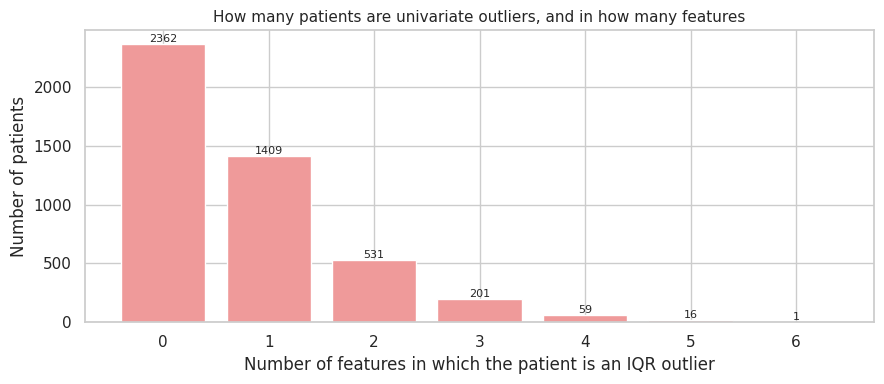

Patients with >=1 IQR outlier feature: 2217 (48.4%)
Patients with >=3 IQR outlier features: 277 (6.0%)


In [4]:
# Per-row count of features in which a patient is a univariate (IQR) outlier
iqr_flags = pd.DataFrame(
    {feat: iqr_mask(Xc[feat])[0] for feat in CONTINUOUS_FEATURES}
)
rows_outlier_count = iqr_flags.sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
vc = rows_outlier_count.value_counts().sort_index()
ax.bar(vc.index, vc.values, color='#EF9A9A')
ax.set_xlabel('Number of features in which the patient is an IQR outlier')
ax.set_ylabel('Number of patients')
ax.set_title('How many patients are univariate outliers, and in how many features',
             fontsize=11)
for x, v in zip(vc.index, vc.values):
    ax.text(x, v, str(v), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print(f'Patients with >=1 IQR outlier feature: '
      f'{(rows_outlier_count > 0).sum()} ({100*(rows_outlier_count > 0).mean():.1f}%)')
print(f'Patients with >=3 IQR outlier features: '
      f'{(rows_outlier_count >= 3).sum()} ({100*(rows_outlier_count >= 3).mean():.1f}%)')

## 3. Distribution & Boxplot Inspection

Boxplots make the extremes visually obvious. Strongly right-skewed features
(troponin, creatinine, glycemia, platelet markers, ...) are shown on a `log1p`
scale so the bulk of the distribution is not crushed against the axis.

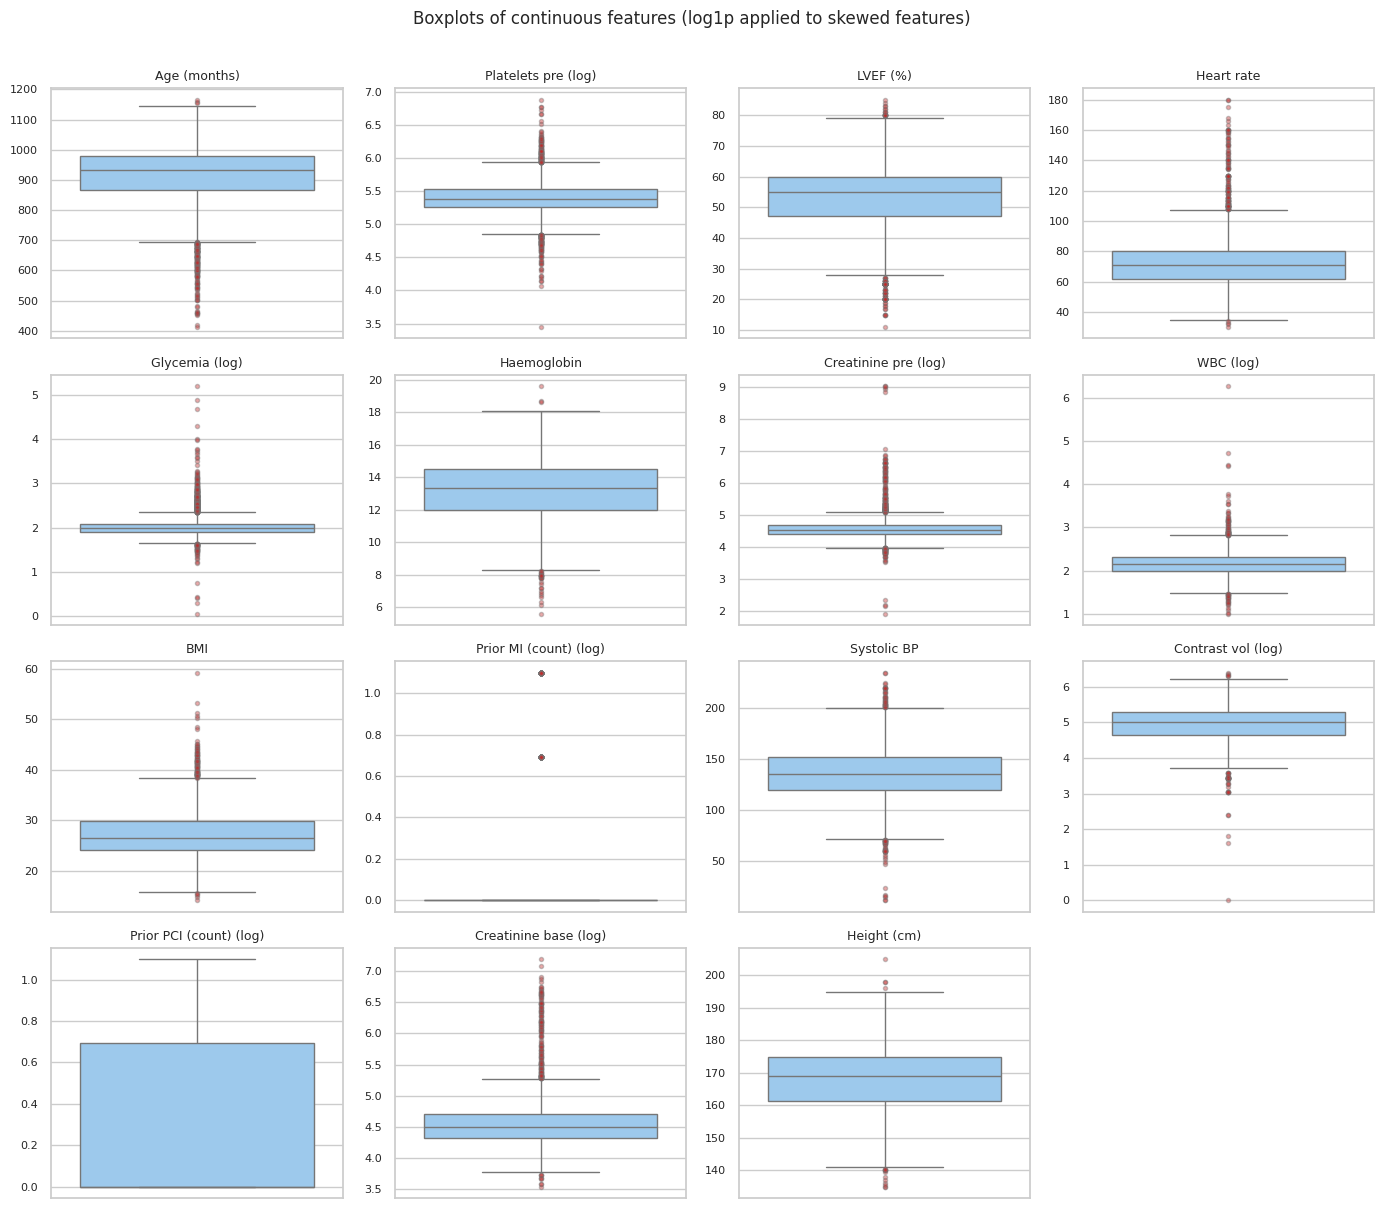

In [5]:
import math

SKEWED = [
    'pci_tropo_pre', 'pci_tropo_ldis', 'pci_creatinine_pre', 'prec_creatinine',
    'prec_wbc', 'pci_platelvol_pre', 'pci_platelvol_ldis', 'pci_glycemia',
    'contrast', 'fup_ccs', 'pci_platel_pre', 'prior_mi', 'prior_pci', 'fup_nyha'
]
SKEWED = [c for c in SKEWED if c in CONTINUOUS_FEATURES]

X_disp = Xc.copy()
X_disp[SKEWED] = np.log1p(X_disp[SKEWED])

ncols = 4
nrows = math.ceil(len(CONTINUOUS_FEATURES) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3))
axes = axes.flatten()

for i, feat in enumerate(CONTINUOUS_FEATURES):
    ax = axes[i]
    sns.boxplot(y=X_disp[feat], ax=ax, color='#90CAF9',
                flierprops=dict(marker='o', markersize=3,
                                markerfacecolor='#C62828', alpha=0.4))
    suffix = ' (log)' if feat in SKEWED else ''
    ax.set_title(shorten(feat) + suffix, fontsize=9)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.tick_params(labelsize=8)

for j in range(len(CONTINUOUS_FEATURES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplots of continuous features (log1p applied to skewed features)',
             fontsize=12, y=1.005)
plt.tight_layout()
plt.show()

## 4. Multivariate Outlier Detection

Univariate rules miss observations that are unremarkable on each single feature but
jointly implausible. Two multivariate views are added:

- **Isolation Forest** – an unsupervised model that isolates anomalies via random
  splits; the `contamination` parameter sets the expected outlier fraction.
- **Robust Mahalanobis distance** – distance from the robust (MCD) centre in the
  correlation-aware metric; under multivariate normality the squared distance follows
  a chi-square with `d` degrees of freedom, giving a principled cut-off.

In [6]:
CONTAMINATION = 0.02   # expected fraction of anomalies for Isolation Forest

# --- Isolation Forest ---
Xs = StandardScaler().fit_transform(Xc)
iso = IsolationForest(contamination=CONTAMINATION, random_state=RANDOM_STATE,
                      n_estimators=300)
iso_pred = iso.fit_predict(Xs)            # -1 = outlier, 1 = inlier
iso_outlier = pd.Series(iso_pred == -1, index=Xc.index)
iso_score = pd.Series(-iso.score_samples(Xs), index=Xc.index)  # higher = more anomalous

# --- Robust Mahalanobis distance (MCD) ---
mcd = MinCovDet(random_state=RANDOM_STATE).fit(Xc.values)
mahal_sq = pd.Series(mcd.mahalanobis(Xc.values), index=Xc.index)
d = Xc.shape[1]
maha_thresh = chi2.ppf(0.975, df=d)
maha_outlier = mahal_sq > maha_thresh

print(f'Isolation Forest flagged: {iso_outlier.sum()} '
      f'({100*iso_outlier.mean():.1f}%) at contamination={CONTAMINATION}')
print(f'Robust Mahalanobis flagged: {maha_outlier.sum()} '
      f'({100*maha_outlier.mean():.1f}%) at chi2_0.975(df={d})={maha_thresh:.1f}')
print(f'Agreement (both methods): {(iso_outlier & maha_outlier).sum()} patients')

Isolation Forest flagged: 92 (2.0%) at contamination=0.02
Robust Mahalanobis flagged: 2052 (44.8%) at chi2_0.975(df=15)=27.5
Agreement (both methods): 92 patients


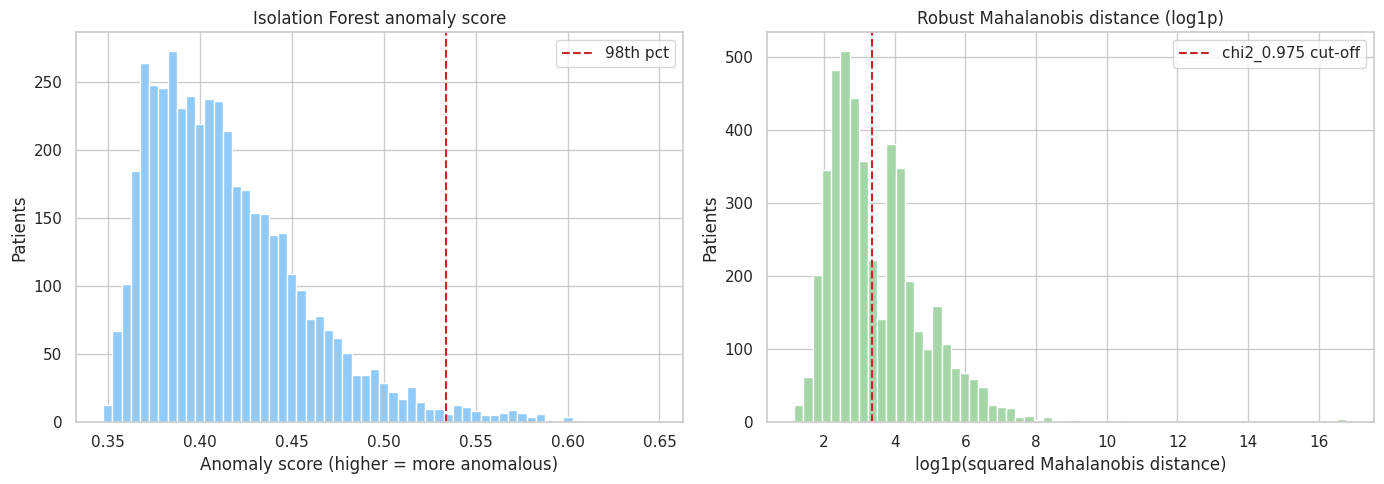

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Isolation Forest score distribution
axes[0].hist(iso_score, bins=60, color='#90CAF9', edgecolor='white')
thr_score = np.quantile(iso_score, 1 - CONTAMINATION)
axes[0].axvline(thr_score, color='#C62828', linestyle='--',
                label=f'{100*(1-CONTAMINATION):.0f}th pct')
axes[0].set_title('Isolation Forest anomaly score')
axes[0].set_xlabel('Anomaly score (higher = more anomalous)')
axes[0].set_ylabel('Patients')
axes[0].legend()

# Mahalanobis distance distribution (log scale for visibility)
axes[1].hist(np.log1p(mahal_sq), bins=60, color='#A5D6A7', edgecolor='white')
axes[1].axvline(np.log1p(maha_thresh), color='#C62828', linestyle='--',
                label=f'chi2_0.975 cut-off')
axes[1].set_title('Robust Mahalanobis distance (log1p)')
axes[1].set_xlabel('log1p(squared Mahalanobis distance)')
axes[1].set_ylabel('Patients')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Optional Outlier Removal

The cell below is the **single place to decide whether and how outliers are removed**.
It is disabled by default (`REMOVE_OUTLIERS = False`) so re-running the notebook never
silently changes the dataset.

Configure:
- `REMOVE_OUTLIERS` – master switch.
- `METHOD` – `'iqr'`, `'robust_z'`, `'isolation_forest'`, `'mahalanobis'`, or
  `'iqr_count'` (drop patients flagged as IQR outliers in at least `MIN_IQR_FEATURES`
  features).
- `MIN_IQR_FEATURES` – threshold for the `'iqr_count'` method.
- `SAVE` – if `True`, writes the filtered `X`/`y` to new parquet files (originals are
  left untouched).

The cell reports how many patients would be dropped and previews the impact before
saving.

In [8]:
# ----------------------------- CONFIG ------------------------------------
REMOVE_OUTLIERS  = True          # master switch
METHOD           = 'iqr_count'    # 'iqr' | 'robust_z' | 'isolation_forest'
                                  # | 'mahalanobis' | 'iqr_count'
MIN_IQR_FEATURES = 3              # only for METHOD == 'iqr_count'
SAVE             = True          # write filtered data to data/*_no_outliers.parquet
# -------------------------------------------------------------------------

def build_outlier_mask(method):
    """Return a boolean Series (True = outlier row) for the chosen method."""
    if method == 'iqr':
        return iqr_flags.any(axis=1)
    if method == 'iqr_count':
        return rows_outlier_count >= MIN_IQR_FEATURES
    if method == 'robust_z':
        z_flags = pd.DataFrame(
            {f: robust_z_mask(Xc[f])[0] for f in CONTINUOUS_FEATURES})
        return z_flags.any(axis=1)
    if method == 'isolation_forest':
        return iso_outlier
    if method == 'mahalanobis':
        return maha_outlier
    raise ValueError(f'Unknown METHOD: {method!r}')

mask = build_outlier_mask(METHOD)
n_out = int(mask.sum())
print(f"Method '{METHOD}' flags {n_out} patients "
      f'({100*mask.mean():.1f}% of {len(mask)}) as outliers.')

if not REMOVE_OUTLIERS:
    print('\nREMOVE_OUTLIERS = False -> dataset left unchanged. '
          'Set it to True to apply the filter.')
    X_clean, y_clean = X, y
else:
    keep = ~mask
    X_clean = X.loc[keep].reset_index(drop=True)
    y_clean = y.loc[keep].reset_index(drop=True)
    print(f'\nRemoved {n_out} patients -> {X_clean.shape[0]} remaining.')

    # Show how target prevalence shifts after removal (clinically important: we do
    # not want to disproportionately discard the rare event cases).
    before = y.mean().rename('before')
    after = y_clean.mean().rename('after')
    prevalence = pd.concat([before, after], axis=1)
    prevalence['delta_pp'] = (prevalence['after'] - prevalence['before']) * 100
    print('\nTarget prevalence before/after removal:')
    display(prevalence.style.format({'before': '{:.3f}', 'after': '{:.3f}',
                                     'delta_pp': '{:+.2f} pp'}))

    if SAVE:
        x_path = os.path.join(PROJECT_DIR, 'data/X_features_no_outliers.parquet')
        y_path = os.path.join(PROJECT_DIR, 'data/y_targets_no_outliers.parquet')
        X_clean.to_parquet(x_path)
        y_clean.to_parquet(y_path)
        print(f'\nSaved:\n  {x_path}\n  {y_path}')
    else:
        print('\nSAVE = False -> filtered data kept in memory only '
              '(X_clean, y_clean).')

Method 'iqr_count' flags 277 patients (6.0% of 4579) as outliers.

Removed 277 patients -> 4302 remaining.

Target prevalence before/after removal:


,before,after,delta_pp
cec_barc235_335d,0.078,0.078,-0.05 pp
cec_cvdeath_335d,0.018,0.014,-0.33 pp
cec_mi_335d,0.024,0.022,-0.22 pp
cec_stroke_335d,0.008,0.007,-0.07 pp
cec_bleed_335d,0.111,0.110,-0.03 pp
cec_barc2_335d,0.055,0.057,+0.15 pp
cec_barc3_335d,0.024,0.023,-0.12 pp
cec_barc35_335d,0.027,0.025,-0.20 pp
cec_revasc_335d,0.035,0.035,-0.03 pp



Saved:
  /home/tpioda/Bachelor-Thesis/data/X_features_no_outliers.parquet
  /home/tpioda/Bachelor-Thesis/data/y_targets_no_outliers.parquet
